In [1]:
'''
Test the aqua implementation of different autapse_mode parameters

'''

'\nTest the aqua implementation of different autapse_mode parameters\n\n'

In [2]:
import sys
sys.path.append("../")

from brian2 import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from aqua.plotting_functions import *
from aqua.utils import *
from aqua.batchAQUA_general import batchAQUA

from functions import *

In [3]:
# strong autaptic neuron on RS resonator...
E1_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 150., 'tau': 0.} # strong autaptic neuron on RS resonator...

T = 1000
dt = 0.01
defaultclock.dt = dt*ms
N_iter = int(T/dt)

N_neurons = 100
params = []
for i in range(N_neurons):
    params.append(E1_neuron)

params_df = pd.DataFrame(params)

# initial conditions
x_start = np.full((N_neurons, 3), fill_value = np.array([[-60., 0., 0.]]))
t_start = np.zeros(N_neurons)

E1 = batchAQUA(params_df)
E1.Initialise(x_start, t_start)

# stimulus
I = 100 * np.ones((N_neurons, N_iter))
I_TA = TimedArray(values = I.T, dt = dt*ms, name = 'I_TA')


''' Convert the neuron to brian2 objects '''
#E1_poisson, gen_poisson, aut_in_poisson, aut_out_poisson = E1.meetBrian(stimulus_name = I_TA, autapse_mode = 'poisson', p1 = 2*ms, p2 = 1)    # autapse delay follows a poisson distribution

#E1_erlang, gen_erlang, aut_in_erlang, aut_out_erlang = E1.meetBrian(stimulus_name = I_TA, autapse_mode = 'erlang', p1 = 2*ms, p2 = 5)    # autapse delay follows a gamma distribution

#E1_normal, gen_normal, aut_in_normal, aut_out_normal = E1.meetBrian(stimulus_name = I_TA, autapse_mode = 'normal', p1 = 5*ms, p2 = 1*ms)    # autapse delay follows a normal distribution

#E1_uniform, gen_uniform, aut_in_uniform, aut_out_uniform = E1.meetBrian(stimulus_name = I_TA, autapse_mode = 'uniform', p1 = 0*ms, p2 = 10*ms)    # autapse delay follows a normal distribution


# create monitor for each neuron's autapes


' Convert the neuron to brian2 objects '

1898
1898


Text(0.5, 1.0, 'Poisson')

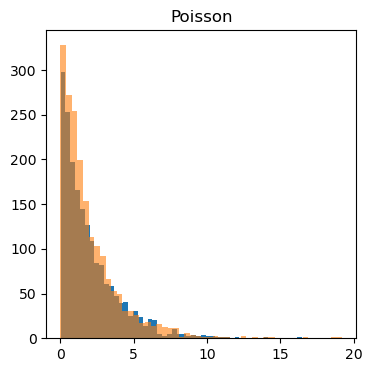

In [ ]:
# First run the standard autapse!
E1_poisson, gen_poisson, aut_in_poisson, aut_out_poisson = E1.meetBrian(stimulus_name = I_TA, autapse_mode = 'poisson', p1 = 2*ms, p2 = 1)    # autapse delay follows a poisson distribution

# create monitors
spikes = SpikeMonitor(E1_poisson, record = True)
aut_spikes = SpikeMonitor(gen_poisson, record = True)


net = Network(E1_poisson, gen_poisson, aut_in_poisson, aut_out_poisson, spikes, aut_spikes)

net.run(T*ms)


spike_train = spikes.spike_trains()
ref_spikes = convert_spikes_to_aqua(spike_train).flatten()
aut_spk_train = aut_spikes.spike_trains()
aut_spikes = convert_spikes_to_aqua(aut_spk_train).flatten()

delay = aut_spikes - ref_spikes
delay = delay[~np.isnan(delay)]

fig, ax = plt.subplots(figsize = (4, 4))
rng = np.random.default_rng()
expo = rng.exponential(scale = 2, size = len(delay))

ax.hist(delay, bins = 50)
ax.hist(expo, bins = 50, alpha = 0.6)
ax.set_title("Poisson")


WARNING    'i' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 99. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'k' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 2. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'dt' is an internal variable of group 'neurongroup_3', but also exists in the run namespace with the value 0.01. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Text(0.5, 1.0, 'Erlang')

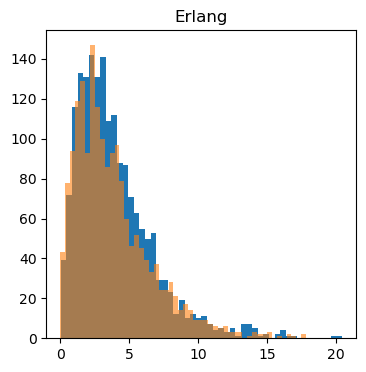

In [5]:

# First run the standard autapse!
k = 2
tau = 2*ms
E1_erlang, gen_erlang, aut_in_erlang, aut_internal_erlang, aut_out_erlang = E1.meetBrian(stimulus_name = I_TA, autapse_mode = 'erlang', p1 = tau, p2 = k)    # autapse delay follows a gamma distribution

# create monitors
spikes = SpikeMonitor(E1_erlang, record = True)
aut_spikes = SpikeMonitor(gen_erlang, record = True)

net = Network(E1_erlang, gen_erlang, aut_in_erlang, aut_internal_erlang, aut_out_erlang, spikes, aut_spikes)
net.run(T*ms)


spike_train = spikes.spike_trains()
ref_spikes = convert_spikes_to_aqua(spike_train)

ref_spikes = ref_spikes.flatten()

# autapse spikes
N_relay = N_neurons * k
out_indices = np.arange(N_relay - N_neurons, N_relay, 1)    # indices of output neurons
aut_spk_dict = aut_spikes.spike_trains()
    
# convert to aqua
aut_spikes = convert_spikes_to_aqua(aut_spk_dict)
aut_spikes = aut_spikes[out_indices, :].flatten()    # only take the output neuron spikes

#aut_spk_train = [v for k, v in aut_spk_dict.items() if k >= N_relay - N_neurons] 
#aut_spikes = convert_spikes_to_aqua(aut_spk_train)#[out_indices].flatten()

delay = aut_spikes - ref_spikes
delay = delay[~np.isnan(delay)]

fig, ax = plt.subplots(figsize = (4, 4))
gamma = 1000*np.random.gamma(k, tau, size = len(delay))


ax.hist(delay, bins = 50)
ax.hist(gamma, bins = 50, alpha = 0.6)
ax.set_title("Erlang")


WARNING    'i' is an internal variable of group 'neurongroup_4', but also exists in the run namespace with the value 99. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'k' is an internal variable of group 'neurongroup_4', but also exists in the run namespace with the value 2. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. 2 lines of abstract code, first line is: 'is_active += 1 (in-place)'
 [brian2.codegen.generators.base]


Text(0.5, 1.0, 'Normal')

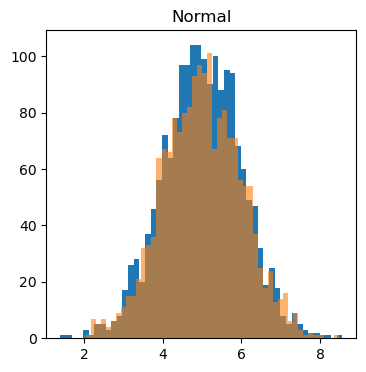

In [6]:
# First run the standard autapse!
E1_normal, gen_normal, aut_in_normal, aut_out_normal = E1.meetBrian(stimulus_name = I_TA, autapse_mode = 'normal', p1 = 5*ms, p2 = 1*ms)    # autapse delay follows a normal distribution

# create monitors
spikes = SpikeMonitor(E1_normal, record = True)
aut_spikes = SpikeMonitor(gen_normal, record = True)


net = Network(E1_normal, gen_normal, aut_in_normal, aut_out_normal, spikes, aut_spikes)

net.run(T*ms)


spike_train = spikes.spike_trains()
ref_spikes = convert_spikes_to_aqua(spike_train).flatten()
aut_spk_train = aut_spikes.spike_trains()
aut_spikes = convert_spikes_to_aqua(aut_spk_train).flatten()

delay = aut_spikes - ref_spikes
delay = delay[~np.isnan(delay)]

fig, ax = plt.subplots(figsize = (4, 4))

normal = np.random.normal(loc = 5, scale = 1., size = len(delay))

ax.hist(delay, bins = 50)
ax.hist(normal, bins = 50, alpha = 0.6)
ax.set_title("Normal")

WARNING    'i' is an internal variable of group 'neurongroup_6', but also exists in the run namespace with the value 99. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'k' is an internal variable of group 'neurongroup_6', but also exists in the run namespace with the value 2. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. 2 lines of abstract code, first line is: 'is_active += 1 (in-place)'
 [brian2.codegen.generators.base]


Text(0.5, 1.0, 'Normal')

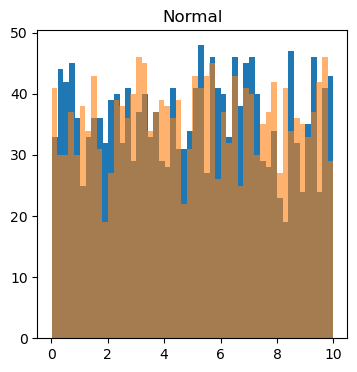

In [7]:
# First run the standard autapse!
E1_uniform, gen_uniform, aut_in_uniform, aut_out_uniform = E1.meetBrian(stimulus_name = I_TA, autapse_mode = 'uniform', p1 = 0*ms, p2 = 10*ms)    # autapse delay follows a normal distribution

# create monitors
spikes = SpikeMonitor(E1_uniform, record = True)
aut_spikes = SpikeMonitor(gen_uniform, record = True)


net = Network(E1_uniform, gen_uniform, aut_in_uniform, aut_out_uniform, spikes, aut_spikes)

net.run(T*ms)


spike_train = spikes.spike_trains()
ref_spikes = convert_spikes_to_aqua(spike_train).flatten()
aut_spk_train = aut_spikes.spike_trains()
aut_spikes = convert_spikes_to_aqua(aut_spk_train).flatten()

delay = aut_spikes - ref_spikes
delay = delay[~np.isnan(delay)]

fig, ax = plt.subplots(figsize = (4, 4))
uniform = np.random.uniform(low = 0, high = 10, size = len(delay))


ax.hist(delay, bins = 50)
ax.hist(uniform, bins = 50, alpha = 0.6)
ax.set_title("Normal")